1. IMPORT LIBRARIES

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. LOAD DATA

In [23]:
df = pd.read_csv(r"C:\Users\yashw\OneDrive - Avinia\github Projects of Priyanka Burra\retail-sales-analysis\data\cleaned\cleaned_sales.csv")

print(df.head())
print(df.info())

         order_id  order_date   ship_date       ship_mode customer_id  \
0  CA-2014-145317  2014-03-18  2014-03-23  Standard Class    SM-20320   
1  CA-2016-118689  2016-10-02  2016-10-09  Standard Class    TC-20980   
2  CA-2017-140151  2017-03-23  2017-03-25     First Class    RB-19360   
3  CA-2017-127180  2017-10-22  2017-10-24     First Class    TA-21385   
4  CA-2017-166709  2017-11-17  2017-11-22  Standard Class    HL-15040   

  customer_name      segment        country           city       state  \
0   Sean Miller  Home Office  United States   Jacksonville     Florida   
1  Tamara Chand    Corporate  United States      Lafayette     Indiana   
2  Raymond Buch     Consumer  United States        Seattle  Washington   
3  Tom Ashbrook  Home Office  United States  New York City    New York   
4  Hunter Lopez     Consumer  United States         Newark    Delaware   

  postal_code   region       product_id    category sub_category  \
0  1988-03-14    South  TEC-MA-10002412  Technol

3. DATA CLEANING

In [24]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Convert data types
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["ship_date"] = pd.to_datetime(df["ship_date"], errors="coerce")

df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df["profit"] = pd.to_numeric(df["profit"], errors="coerce")
df["discount"] = pd.to_numeric(df["discount"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.dropna()

print("After cleaning:", df.shape)

After cleaning: (300, 20)


4. FEATURE ENGINEERING

In [25]:
# Time features
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.to_period("M").astype(str)

# Business metric
df["profit_margin"] = np.where(df["sales"] != 0, df["profit"] / df["sales"], 0)

# NEW METRIC (ADD HERE)
df["avg_order_value"] = np.where(df["quantity"] != 0, df["sales"] / df["quantity"], 0)

print(df.head())

         order_id order_date  ship_date       ship_mode customer_id  \
0  CA-2014-145317 2014-03-18 2014-03-23  Standard Class    SM-20320   
1  CA-2016-118689 2016-10-02 2016-10-09  Standard Class    TC-20980   
2  CA-2017-140151 2017-03-23 2017-03-25     First Class    RB-19360   
3  CA-2017-127180 2017-10-22 2017-10-24     First Class    TA-21385   
4  CA-2017-166709 2017-11-17 2017-11-22  Standard Class    HL-15040   

  customer_name      segment        country           city       state  ...  \
0   Sean Miller  Home Office  United States   Jacksonville     Florida  ...   
1  Tamara Chand    Corporate  United States      Lafayette     Indiana  ...   
2  Raymond Buch     Consumer  United States        Seattle  Washington  ...   
3  Tom Ashbrook  Home Office  United States  New York City    New York  ...   
4  Hunter Lopez     Consumer  United States         Newark    Delaware  ...   

  sub_category                                       product_name    sales  \
0     Machines  Cisc

5. CUSTOMER ANALYSIS

In [26]:
customer_df = df.groupby(["customer_id", "customer_name"]).agg(
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    total_orders=("order_id", "nunique"),
    total_quantity=("quantity", "sum")
).reset_index()

print(customer_df.head())

  customer_id    customer_name  total_sales  total_profit  total_orders  \
0    AA-10315       Alex Avila      3930.07       -786.01             1   
1    AB-10060  Adam Bellavance      6392.03       1782.06             2   
2    AB-10105    Adrian Barton      9892.74       4946.37             1   
3    AC-10450          Amy Cox      3459.60        876.48             2   
4    AD-10180   Alan Dominguez      2999.95       1379.98             1   

   total_quantity  
0               3  
1              11  
2              13  
3               4  
4               5  


6. SAVE PROCESSED FILES

In [27]:
import os

os.makedirs("data/processed", exist_ok=True)

df.to_csv("data/processed/fact_sales.csv", index=False)
customer_df.to_csv("data/processed/dim_customers.csv", index=False)

7. EDA (VISUALIZATION)
7.1 Monthly Sales Trend

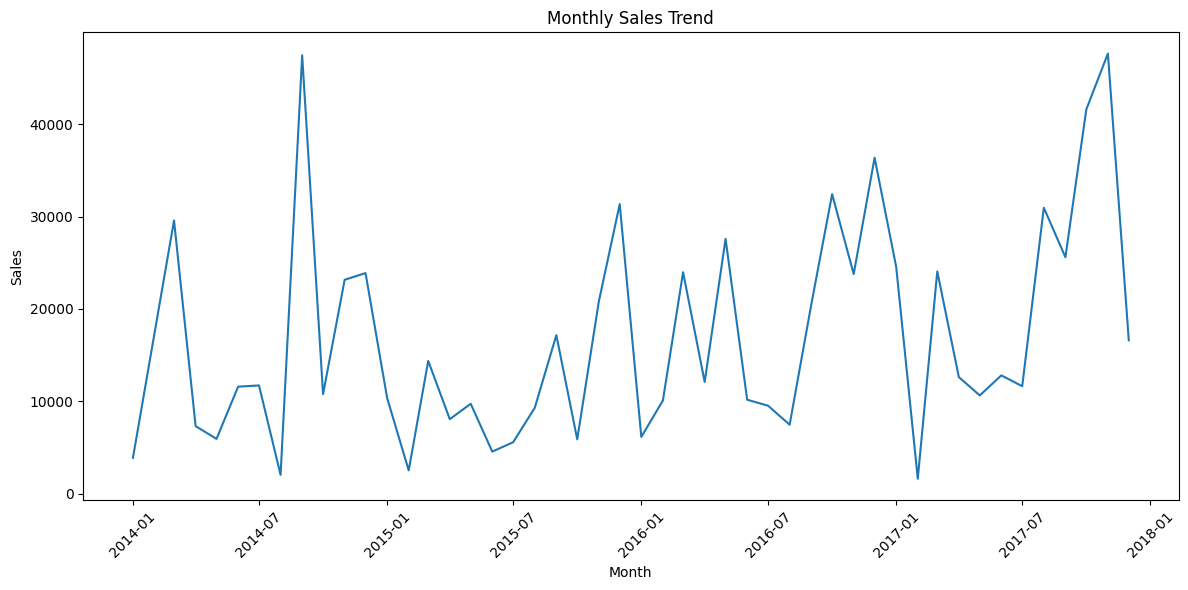

In [28]:
monthly = df.groupby("order_month")["sales"].sum().reset_index()

# Fix sorting issue
monthly["order_month"] = pd.to_datetime(monthly["order_month"])
monthly = monthly.sort_values("order_month")

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly, x="order_month", y="sales")
plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

7.2 Profit by Category

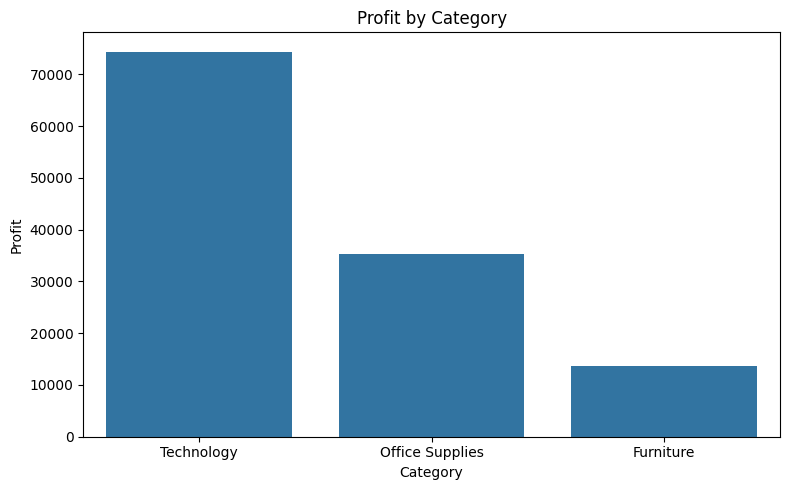

In [35]:
category_profit = df.groupby("category")["profit"].sum().reset_index()
category_profit = category_profit.sort_values("profit", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=category_profit, x="category", y="profit")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()   # ⭐ optional but recommended
plt.show()

7.3 Top 10 Customers

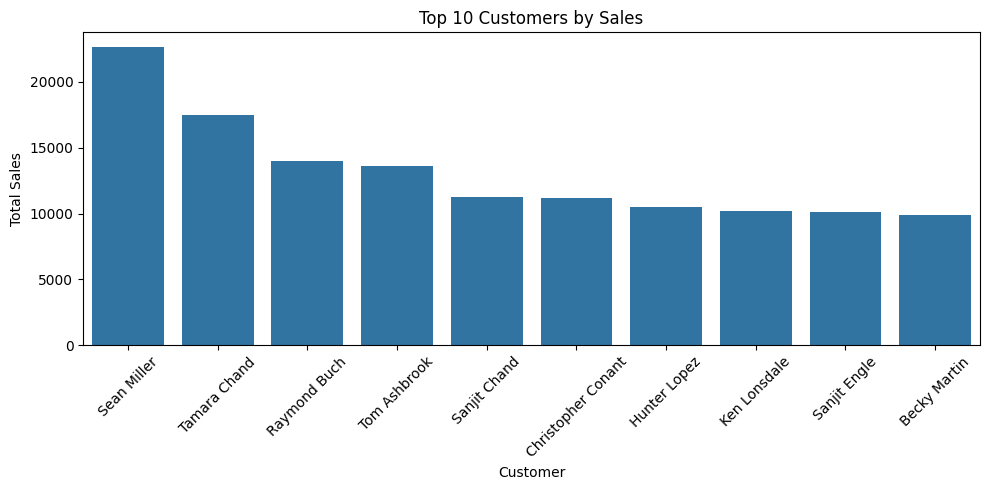

In [30]:
top_customers = customer_df.sort_values("total_sales", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top_customers, x="customer_name", y="total_sales")

plt.xticks(rotation=45)
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Total Sales")

plt.tight_layout()   # ✅ correct place
plt.show()

7.4 Sales by Region

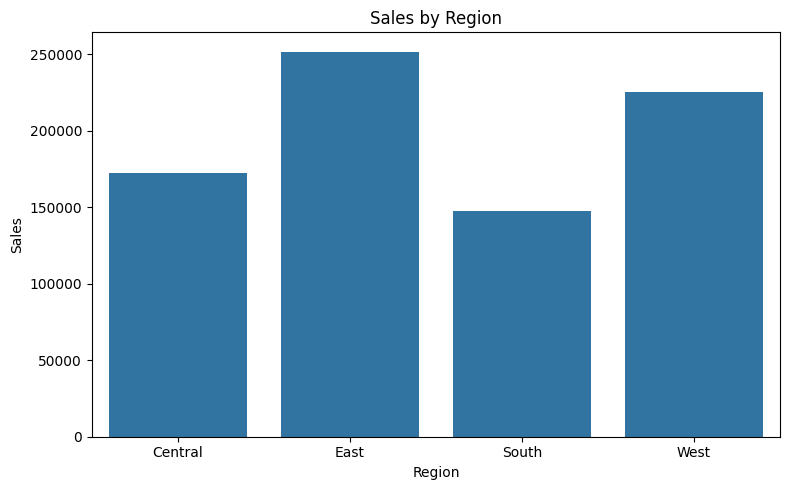

In [31]:
region_sales = df.groupby("region")["sales"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=region_sales, x="region", y="sales")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.tight_layout()  
plt.show()

7.5 Discount vs Profit

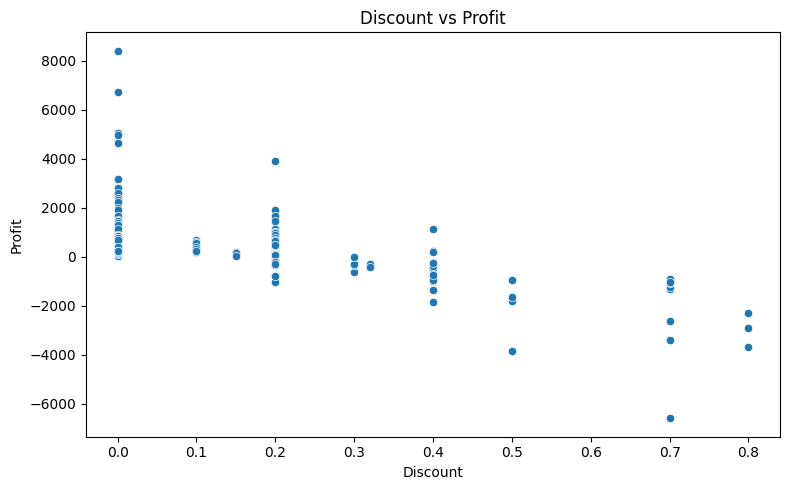

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="discount", y="profit")

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()  
plt.show()

Profit by Sub-category

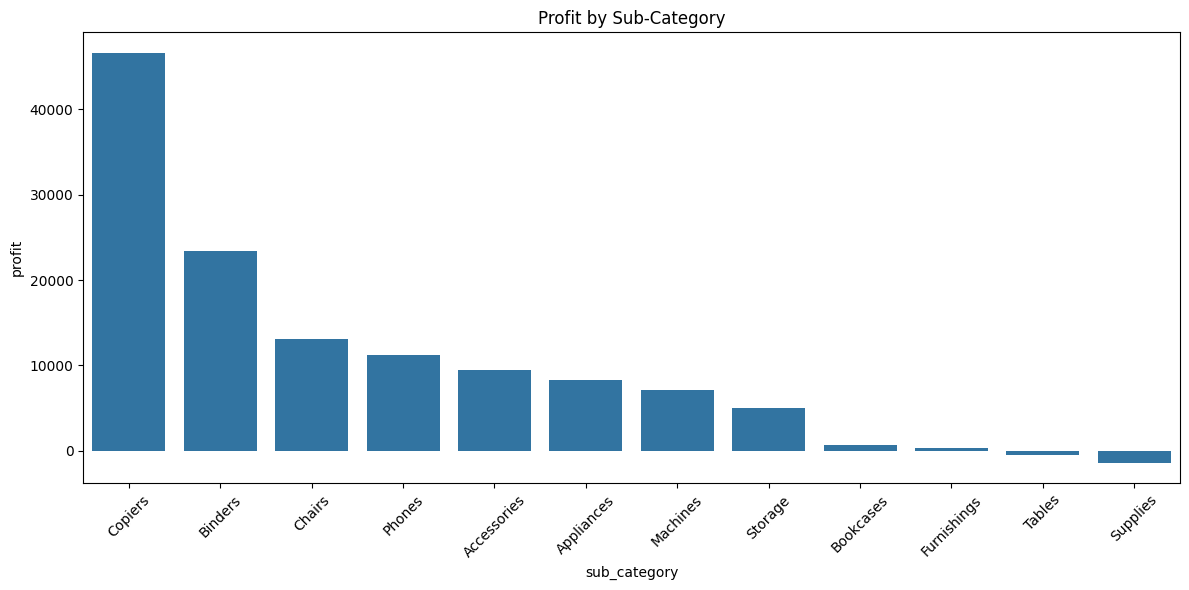

In [33]:
subcat = df.groupby("sub_category")["profit"].sum().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=subcat.sort_values("profit", ascending=False),
            x="sub_category", y="profit")

plt.xticks(rotation=45)
plt.title("Profit by Sub-Category")
plt.tight_layout()  
plt.show()

Key Insights:

1. Technology category generates highest profit.
2. High discounts reduce profit significantly.
3. Sales show fluctuations across months (seasonality).
4. Few customers contribute most of the revenue.
5. Some regions perform better than others.